In [1]:
import os
from collections import defaultdict
import time
from tqdm import tqdm
import cv2
import torch
import torch.nn as nn
import torchvision
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader
from torchsummary import summary
import torch.optim as optim

from sklearn.metrics import f1_score, confusion_matrix

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import wandb

try:
    from kaggle_secrets import UserSecretsClient
    user_secrets = UserSecretsClient()
    api_key = user_secrets.get_secret("wandb_api")
    wandb.login(key=api_key)
    anony = None
except:
    anony = "must"
    print('If you want to use your W&B account, go to Add-ons -> Secrets and provide your W&B access token. Use the Label name as wandb_api. \nGet your W&B access token from here: https://wandb.ai/authorize')

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: iq000012 (infinitasfish). Use `wandb login --relogin` to force relogin
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


# Data prep

In [3]:
import kagglehub

path = kagglehub.dataset_download("fedesoriano/cifar10-python-in-csv")
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/cifar10-python-in-csv


In [4]:
for i, j, k in os.walk(path):
    print(i, j, k)

/kaggle/input/cifar10-python-in-csv [] ['batches.meta', 'train.csv', 'test.csv']


In [5]:
ds = pd.read_csv(os.path.join(path, 'train.csv'))
ds_ = pd.read_csv(os.path.join(path, 'test.csv'))
print(ds.shape)
print(ds_.shape)

(50000, 3073)
(10000, 3072)


6


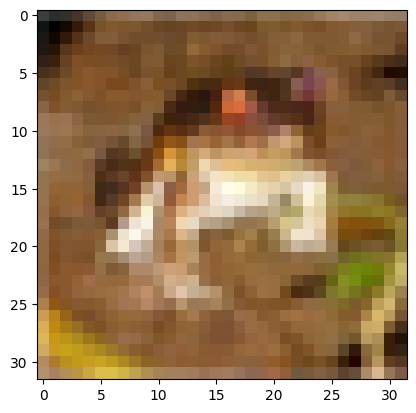

In [6]:
image, label = ds.iloc[0].values[:-1].reshape(3, 32, 32), ds.iloc[0].values[-1]
print(label)
plt.imshow(np.transpose(image, (1, 2, 0)))
# froggy

In [7]:
class cifar_10(Dataset):
    def __init__(self, csv_path, split=None, train_tform=None, test_tform=None):
        self.split = split
        if self.split == 'train':
            self.dsdf = pd.read_csv(os.path.join(csv_path, 'train.csv'))
        elif self.split == 'test':
            self.dsdf = pd.read_csv(os.path.join(csv_path, 'test.csv'))
        else:
            raise ValueError('-.-')
            
        self.train_tform = train_tform
        self.test_tform = test_tform
        
    def __len__(self):
        return len(self.dsdf)

    def __getitem__(self, idx):
        image = self.dsdf.iloc[idx].values[:-1].reshape(3, 32, 32)
        image = np.transpose(image, (1, 2, 0)).astype(np.float32)
        label = self.dsdf.iloc[idx].values[-1]
        if self.split == 'train':
            t_image = self.train_tform(image)
        elif self.split == 'test':
            t_image = self.test_tform(image)
        return t_image, label
        

In [8]:
transform_train = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(0.5),
    transforms.ColorJitter(0.1, 0.1, 0.1),
    transforms.ToTensor(),
    transforms.Resize((32,32)),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.5,scale=(0.02, 0.1),value=1.0, inplace=False),
])

transform_test = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Resize((32,32)),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


In [9]:
generator1 = torch.Generator().manual_seed(59)
generator2 = torch.Generator().manual_seed(59)

all_ds = cifar_10(path, split='train', train_tform=transform_train)
train_ds, val_ds = torch.utils.data.random_split(all_ds, [0.8, 0.2])
val_ds.train_tform = transform_train
test_ds = cifar_10(path, split='test', test_tform=transform_test)

trainloader = DataLoader(train_ds, batch_size=256, shuffle=True)
valloader = DataLoader(val_ds, batch_size=256, shuffle=False)
testloader = DataLoader(val_ds, batch_size=256, shuffle=False)

torch.Size([3, 32, 32])


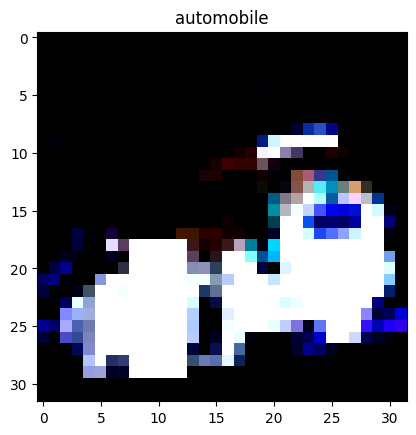

In [10]:
for data in valloader:
    image, label = data
    break
    
i = 11
plt.title(classes[label[i].item()])
plt.imshow(image[i].squeeze().permute(1, 2, 0).cpu().numpy())
print(image[i].shape)

# Teacher-student

In [35]:
# lazy bum
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
# teacher
teacher_model = models.mobilenet_v3_large()
teacher_model.classifier[3] = nn.Linear(teacher_model.classifier[3].in_features, 10)
teacher_model = teacher_model.to(device)

student_model = models.mobilenet_v3_small()
student_model.classifier[3] = nn.Linear(student_model.classifier[3].in_features, 10)
student_model = student_model.to(device)

# large and small Trainable params: ~2.5M, ~5.5M
# summary(teacher_model, (3, 32, 32))
# summary(student_model, (3, 32, 32))

In [31]:

def train_model(model, trainloader, valloader, metrics, num_epochs, lr, device, is_teach):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    for epoch in range(num_epochs):
        running_train_loss = 0.0
        running_val_loss = 0.0
        val_f1 = 0.0

        model.train()
        for i, data in enumerate(trainloader, 0):
            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_train_loss += loss.item()

        model.eval()
        for i, data in enumerate(valloader, 0):
            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item()
            preds = outputs.detach().argmax(dim=1).cpu().numpy()
            val_f1 += f1_score(labels.cpu().numpy(), preds, average='macro')

        train_loss = running_train_loss / len(trainloader)
        val_loss = running_val_loss / len(valloader)
        f1 = val_f1 / len(valloader)

        pref = 'teach_' if is_teach else 'stud_'
        metrics[pref+'train_loss'].append(train_loss)
        metrics[pref+'val_loss'].append(val_loss)
        metrics[pref+'val_f1'].append(f1)
        wandb.log({'epoch': epoch,
                    pref+'train_loss': train_loss,
                    pref+'val_loss': val_loss,
                    pref+'val_f1': f1})

        print(f"Epoch {epoch + 1}, train loss: {train_loss:.5f}, val loss: {val_loss:.5f}, val F1: {f1:.5f}")


In [32]:
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
num_epochs = 25
lr = 1e-4
metrics = defaultdict(list)
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

In [49]:
run = wandb.init(
    project="_teach-stud_train_",
    config={
        "learning_rate": lr,
        "epochs": num_epochs,
    },
)

In [39]:
train_model(teacher_model, trainloader, valloader, metrics, num_epochs, lr, device, is_teach=True)

Epoch 1, train loss: 1.67613, val loss: 1.82922, val F1: 0.36644
Epoch 2, train loss: 1.61052, val loss: 1.64687, val F1: 0.38723
Epoch 3, train loss: 1.55998, val loss: 1.59696, val F1: 0.39463
Epoch 4, train loss: 1.51711, val loss: 1.56477, val F1: 0.40993
Epoch 5, train loss: 1.47646, val loss: 1.53615, val F1: 0.42051
Epoch 6, train loss: 1.44679, val loss: 1.51844, val F1: 0.44180
Epoch 7, train loss: 1.41568, val loss: 1.49602, val F1: 0.44625
Epoch 8, train loss: 1.38661, val loss: 1.47169, val F1: 0.45429
Epoch 9, train loss: 1.35307, val loss: 1.46468, val F1: 0.46265
Epoch 10, train loss: 1.33515, val loss: 1.43418, val F1: 0.47052
Epoch 11, train loss: 1.30891, val loss: 1.43243, val F1: 0.46799
Epoch 12, train loss: 1.29051, val loss: 1.42339, val F1: 0.47988
Epoch 13, train loss: 1.26911, val loss: 1.41520, val F1: 0.47658
Epoch 14, train loss: 1.24458, val loss: 1.40602, val F1: 0.48405
Epoch 15, train loss: 1.22284, val loss: 1.38910, val F1: 0.48851
Epoch 16, train los

In [40]:
train_model(student_model, trainloader, valloader, metrics, num_epochs, lr, device, is_teach=False)

Epoch 1, train loss: 2.18355, val loss: 2.30306, val F1: 0.01911
Epoch 2, train loss: 1.94272, val loss: 2.30462, val F1: 0.01748
Epoch 3, train loss: 1.82146, val loss: 2.30136, val F1: 0.04191
Epoch 4, train loss: 1.74529, val loss: 2.12310, val F1: 0.18402
Epoch 5, train loss: 1.68511, val loss: 1.74246, val F1: 0.35811
Epoch 6, train loss: 1.63842, val loss: 1.65879, val F1: 0.37855
Epoch 7, train loss: 1.59597, val loss: 1.62008, val F1: 0.39251
Epoch 8, train loss: 1.56235, val loss: 1.58657, val F1: 0.40632
Epoch 9, train loss: 1.53029, val loss: 1.56302, val F1: 0.42159
Epoch 10, train loss: 1.50469, val loss: 1.54350, val F1: 0.42652
Epoch 11, train loss: 1.47667, val loss: 1.52134, val F1: 0.43536
Epoch 12, train loss: 1.45503, val loss: 1.50914, val F1: 0.44049
Epoch 13, train loss: 1.43789, val loss: 1.47619, val F1: 0.44507
Epoch 14, train loss: 1.41518, val loss: 1.47268, val F1: 0.45404
Epoch 15, train loss: 1.39958, val loss: 1.46908, val F1: 0.45953
Epoch 16, train los

In [41]:
torch.save(teacher_model, 'teacher.pt')
torch.save(student_model, 'student.pt')

In [42]:
del teacher_model
del student_model

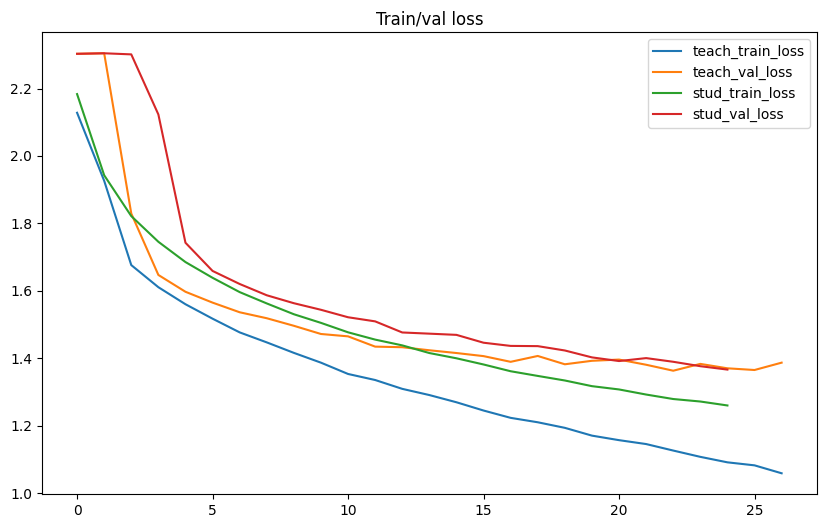

In [47]:
_, ax = plt.subplots(1,1,figsize=(10,6))
ax.set_title('Train/val loss')
ax.plot(metrics['teach_train_loss'], label='teach_train_loss')
ax.plot(metrics['teach_val_loss'], label='teach_val_loss')
ax.plot(metrics['stud_train_loss'], label='stud_train_loss')
ax.plot(metrics['stud_val_loss'], label='stud_val_loss')
ax.legend()

In [48]:
max_f1_teach, max_f1_stud = max(metrics['teach_val_f1']), max(metrics['stud_val_f1'])
print(f"best f1 teacher: {max_f1_teach:.5f}, best f1 stud: {max_f1_stud:.5f}")

best f1 teacher: 0.51220, best f1 stud: 0.49558


# Logit distill

In [13]:
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'

teacher_model_trained = torch.load('/kaggle/input/teacher_student/pytorch/ts/1/teacher.pt', weights_only=False)
student_model_trained = torch.load('/kaggle/input/teacher_student/pytorch/ts/1/student.pt', weights_only=False)

teacher_model_trained.to(device)
student_model_trained.to(device);

In [20]:
import torch.nn.functional as F

def train_model_distill(teach_model, stud_model, trainloader, valloader, metrics, num_epochs, lr, temp=0.2, alpha=0.2, device='cuda:0'):
    criterion = nn.CrossEntropyLoss()
    kl_loss = nn.KLDivLoss(reduction='batchmean')
    optimizer = optim.Adam(stud_model.parameters(), lr=lr)

    for epoch in range(num_epochs):
        running_train_loss = 0.0
        running_val_loss = 0.0
        val_f1 = 0.0

        stud_model.train()
        for i, data in enumerate(trainloader, 0):
            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            
            with torch.no_grad():
                teach_outputs = teach_model(inputs)
            stud_outputs = stud_model(inputs)
            
            loss_ce = criterion(stud_outputs, labels)
            teach_probs = F.softmax(teach_outputs / temp, dim=1)
            stud_log_probs = F.log_softmax(stud_outputs / temp, dim=1)
            loss_kl = kl_loss(stud_log_probs, teach_probs)

            loss = loss_ce + alpha * loss_kl
            loss.backward()
            optimizer.step()
            running_train_loss += loss.item()

        stud_model.eval()
        for i, data in enumerate(valloader, 0):
            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device)
            
            outputs = stud_model(inputs)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item()
            
            preds = outputs.detach().argmax(dim=1).cpu().numpy()
            val_f1 += f1_score(labels.cpu().numpy(), preds, average='macro')

        train_loss = running_train_loss / len(trainloader)
        val_loss = running_val_loss / len(valloader)
        f1 = val_f1 / len(valloader)

        pref = 'stud_distill_'
        metrics[pref+'train_loss'].append(train_loss)
        metrics[pref+'val_loss'].append(val_loss)
        metrics[pref+'val_f1'].append(f1)
        wandb.log({'epoch': epoch,
                    pref+'train_loss': train_loss,
                    pref+'val_loss': val_loss,
                    pref+'val_f1': f1})

        print(f"Epoch {epoch + 1}, train loss: {train_loss:.5f}, val loss: {val_loss:.5f}, val F1: {f1:.5f}")


In [14]:

num_epochs = 20
lr = 1e-4
metrics_distill = defaultdict(list)
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

In [21]:
train_model_distill(teacher_model_trained, student_model_trained, trainloader, valloader, metrics_distill, num_epochs, lr, temp=0.2, alpha=0.2, device=device)

Epoch 1, train loss: 1.62554, val loss: 1.32120, val F1: 0.53111
Epoch 2, train loss: 1.61172, val loss: 1.31042, val F1: 0.53538
Epoch 3, train loss: 1.60069, val loss: 1.31659, val F1: 0.53437
Epoch 4, train loss: 1.58326, val loss: 1.30682, val F1: 0.53642
Epoch 5, train loss: 1.57181, val loss: 1.30083, val F1: 0.53857
Epoch 6, train loss: 1.56279, val loss: 1.29108, val F1: 0.53939
Epoch 7, train loss: 1.55186, val loss: 1.28704, val F1: 0.53395
Epoch 8, train loss: 1.54759, val loss: 1.27743, val F1: 0.53699
Epoch 9, train loss: 1.54140, val loss: 1.28383, val F1: 0.54635
Epoch 10, train loss: 1.52427, val loss: 1.28227, val F1: 0.54216
Epoch 11, train loss: 1.51650, val loss: 1.27284, val F1: 0.54720
Epoch 12, train loss: 1.51227, val loss: 1.27356, val F1: 0.54917
Epoch 13, train loss: 1.50796, val loss: 1.26665, val F1: 0.54995
Epoch 14, train loss: 1.49273, val loss: 1.26353, val F1: 0.54906
Epoch 15, train loss: 1.48775, val loss: 1.25427, val F1: 0.55000
Epoch 16, train los

In [26]:
torch.save(student_model_trained, 'distill_student.pt')

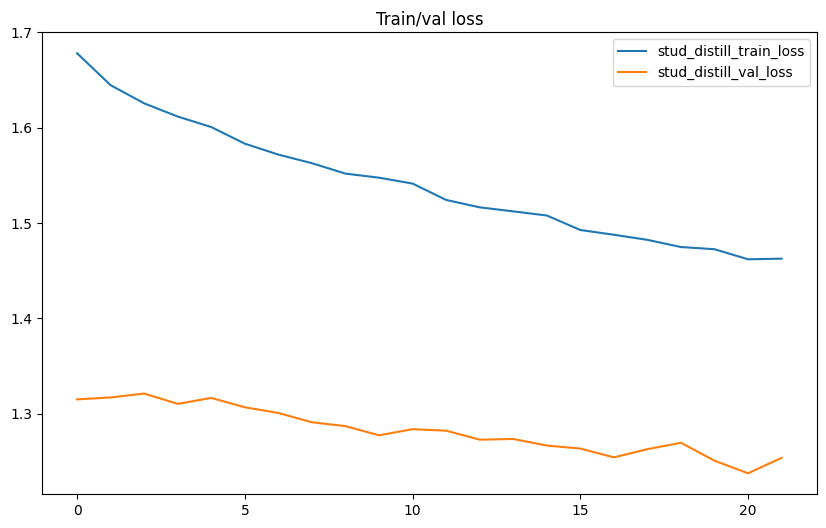

In [22]:
_, ax = plt.subplots(1,1,figsize=(10,6))
ax.set_title('Train/val loss')
ax.plot(metrics_distill['stud_distill_train_loss'], label='stud_distill_train_loss')
ax.plot(metrics_distill['stud_distill_val_loss'], label='stud_distill_val_loss')
ax.legend()

In [25]:
max_f1_stud_distill = max(metrics_distill['stud_distill_val_f1'])
print(f"best f1 stud: {max_f1_stud_distill:.5f}")

best f1 stud: 0.55808


In [27]:
del teacher_model_trained
del student_model_trained

# Hidden state immitation

In [11]:
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
teacher_model_trained = torch.load('/kaggle/input/teacher_student/pytorch/ts/1/teacher.pt', weights_only=False)
student_model_distill_trained = torch.load('/kaggle/input/distil_st/pytorch/distil_st/1/distill_student.pt', weights_only=False)

teacher_model_trained.to(device)
student_model_distill_trained.to(device);

In [12]:
num_epochs = 20
lr = 1e-4
metrics_distill_cosine = defaultdict(list)
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

In [50]:
class cosine_loss(nn.Module):
    def __init__(self):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool1d(576)

    def forward(self, features_teacher, features_student):
        features_teacher = torch.flatten(features_teacher, start_dim=1).unsqueeze(1)
        features_teacher = self.pool(features_teacher)

        return 1 - nn.functional.cosine_similarity(
            features_teacher.view(features_teacher.size(0), -1),
            features_student.view(features_student.size(0), -1),
            dim=1
        ).mean()


def train_model_distill_with_cosine_loss(teach_model, stud_model, trainloader, valloader, metrics, num_epochs, lr, device, alpha=0.15):
    criterion = nn.CrossEntropyLoss()
    cos_loss = cosine_loss()

    optimizer = optim.Adam(stud_model.parameters(), lr=lr)

    for epoch in range(num_epochs):
        running_train_loss = 0.0
        running_val_loss = 0.0
        val_f1 = 0.0

        teach_model.eval()
        stud_model.train()
        for i, data in enumerate(trainloader, 0):
            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            stud_outputs = stud_model(inputs)
            
            features_student = stud_model.features(inputs)
            features_teacher = teach_model.features(inputs)

            # with torch.no_grad():
            #     teach_outputs = teach_model(inputs)
    
            loss_ce = criterion(stud_outputs, labels)
            loss_cosine = cos_loss(features_teacher, features_student)
            loss = loss_ce + alpha * loss_cosine
            loss.backward()
            optimizer.step()

            running_train_loss += loss.item()

        stud_model.eval()
        for i, data in enumerate(valloader, 0):
            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device)

            stud_outputs = stud_model(inputs)
            loss_ce = criterion(stud_outputs, labels)
            running_val_loss += loss_ce.item()

            preds = stud_outputs.detach().argmax(dim=1).cpu().numpy()
            val_f1 += f1_score(labels.cpu().numpy(), preds, average='macro')

        train_loss = running_train_loss / len(trainloader)
        val_loss = running_val_loss / len(valloader)
        f1 = val_f1 / len(valloader)

        pref = 'stud_cosine_'
        metrics[pref+'train_loss'].append(train_loss)
        metrics[pref+'val_loss'].append(val_loss)
        metrics[pref+'val_f1'].append(f1)

        wandb.log({'epoch': epoch,
                    pref+'train_loss': train_loss,
                    pref+'val_loss': val_loss,
                    pref+'val_f1': f1})

        print(f"Epoch {epoch + 1}, train loss: {train_loss:.5f}, val loss: {val_loss:.5f}, val F1: {f1:.5f}")

In [51]:
train_model_distill_with_cosine_loss(teacher_model_trained, student_model_distill_trained,
                                     trainloader, valloader, metrics_distill_cosine, num_epochs, 
                                     lr, device, alpha=0.15)

Epoch 1, train loss: 1.25453, val loss: 1.12004, val F1: 0.58895
Epoch 2, train loss: 1.23399, val loss: 1.10714, val F1: 0.59686
Epoch 3, train loss: 1.21548, val loss: 1.12830, val F1: 0.57746
Epoch 4, train loss: 1.19877, val loss: 1.12168, val F1: 0.58976
Epoch 5, train loss: 1.19033, val loss: 1.12776, val F1: 0.58077
Epoch 6, train loss: 1.18047, val loss: 1.12750, val F1: 0.59193
Epoch 7, train loss: 1.16408, val loss: 1.12985, val F1: 0.58656
Epoch 8, train loss: 1.15759, val loss: 1.13005, val F1: 0.59154
Epoch 9, train loss: 1.14846, val loss: 1.12266, val F1: 0.59002
Epoch 10, train loss: 1.13597, val loss: 1.14008, val F1: 0.57746
Epoch 11, train loss: 1.13278, val loss: 1.14183, val F1: 0.58433
Epoch 12, train loss: 1.12893, val loss: 1.13539, val F1: 0.58350
Epoch 13, train loss: 1.11619, val loss: 1.13965, val F1: 0.58682
Epoch 14, train loss: 1.10543, val loss: 1.13072, val F1: 0.58906
Epoch 15, train loss: 1.09693, val loss: 1.14695, val F1: 0.58906
Epoch 16, train los

In [52]:
torch.save(student_model_distill_trained, 'distill_cosine_student.pt')

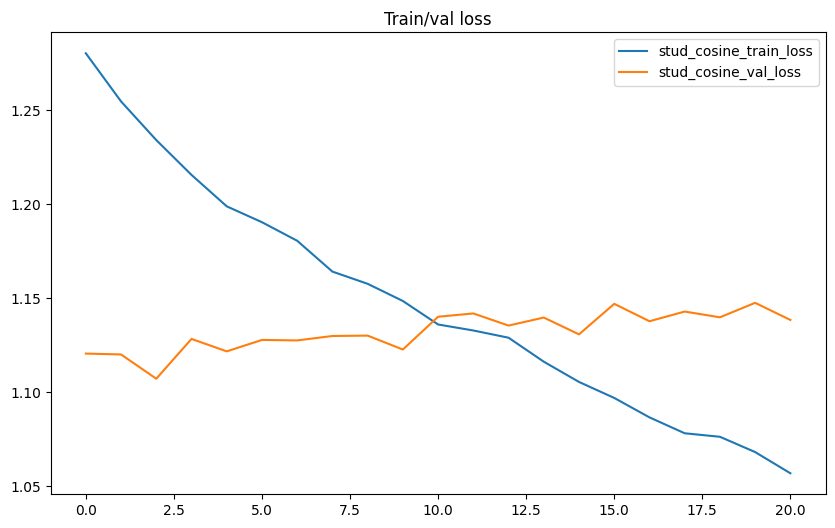

In [53]:
_, ax = plt.subplots(1,1,figsize=(10,6))
ax.set_title('Train/val loss')
ax.plot(metrics_distill_cosine['stud_cosine_train_loss'], label='stud_cosine_train_loss')
ax.plot(metrics_distill_cosine['stud_cosine_val_loss'], label='stud_cosine_val_loss')
ax.legend()

In [54]:
max_f1_stud_distill_cosine = max(metrics_distill_cosine['stud_cosine_val_f1'])
print(f"best f1 stud: {max_f1_stud_distill_cosine:.5f}")

best f1 stud: 0.59686


In [55]:
del teacher_model_trained
del student_model_distill_trained

# Trainable conv2d

In [67]:
class conv_in_between(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(in_channels=960, out_channels=576, kernel_size=1)

    def forward(self, features_teacher):
        self.conv.to(features_teacher.device)
        features_teacher = self.conv(features_teacher)

        return features_teacher

In [68]:
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
teacher_model_trained = torch.load('/kaggle/input/teacher_student/pytorch/ts/1/teacher.pt', weights_only=False)
student_model_distill_trained = torch.load('/kaggle/input/distil_st/pytorch/distil_st/1/distill_student.pt', weights_only=False)
trainable_conv2d = conv_in_between()

teacher_model_trained.to(device)
student_model_distill_trained.to(device)
trainable_conv2d.to(device);

In [69]:

def train_model_distill_with_tconv2d(teach_model, stud_model, tconv2d, trainloader, valloader, metrics, num_epochs, lr, device, alpha=0.15):
    teach_model.eval()
    criterion = nn.CrossEntropyLoss()
    mse_loss = nn.MSELoss(reduction='mean')
    cos_loss = cosine_loss()

    optimizer = optim.Adam(stud_model.parameters(), lr=lr)

    for epoch in range(num_epochs):
        running_train_loss = 0.0
        running_val_loss = 0.0
        conv_train_mse = 0.0
        conv_val_mse = 0.0
        val_f1 = 0.0
        
        stud_model.train()
        tconv2d.train()
        for i, data in enumerate(trainloader, 0):
            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            stud_outputs = stud_model(inputs)
            
            features_student = stud_model.features(inputs)
            features_teacher = teach_model.features(inputs)
            features_teacher = tconv2d(features_teacher)

            loss_ce = criterion(stud_outputs, labels)
            loss_mse = mse_loss(features_student, features_teacher)
            conv_train_mse += loss_mse.item()
            
            loss = loss_ce + alpha * loss_mse
            loss.backward()
            optimizer.step()

            running_train_loss += loss.item()
            

        stud_model.eval()
        tconv2d.eval()
        for i, data in enumerate(valloader, 0):
            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device)

            stud_outputs = stud_model(inputs)
            loss_ce = criterion(stud_outputs, labels)

            features_student = stud_model.features(inputs)
            features_teacher = teach_model.features(inputs)
            features_teacher = tconv2d(features_teacher)
            loss_mse = mse_loss(features_student, features_teacher)
            conv_val_mse += loss_mse.item()
            
            loss = loss_ce + alpha * loss_mse
            running_val_loss += loss.item()

            preds = stud_outputs.detach().argmax(dim=1).cpu().numpy()
            val_f1 += f1_score(labels.cpu().numpy(), preds, average='macro')

        train_loss = running_train_loss / len(trainloader)
        val_loss = running_val_loss / len(valloader)
        train_mse = conv_train_mse / len(trainloader)
        val_mse = conv_val_mse / len(valloader)
        f1 = val_f1 / len(valloader)

        pref = 'stud_conv2d_'
        metrics[pref+'train_loss'].append(train_loss)
        metrics[pref+'val_loss'].append(val_loss)
        metrics[pref+'train_mse_loss'].append(train_mse)
        metrics[pref+'val_mse_loss'].append(val_mse)
        metrics[pref+'val_f1'].append(f1)

        wandb.log({'epoch': epoch,
                    pref+'train_loss': train_loss,
                    pref+'val_loss': val_loss,
                    pref+'train_mse_loss': train_mse,
                    pref+'val_mse_loss': val_mse,
                    pref+'val_f1': f1})

        print(f"Epoch {epoch + 1}, train loss: {train_loss:.5f}, val loss: {val_loss:.5f}, val F1: {f1:.5f}, train mse: {train_mse:.5f}, val mse: {val_mse:.5f}")

In [70]:
num_epochs = 20
lr = 1e-4
metrics_distill_conv2d = defaultdict(list)
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

In [71]:
train_model_distill_with_tconv2d(teacher_model_trained, student_model_distill_trained, trainable_conv2d,
                                 trainloader, valloader, metrics_distill_conv2d, num_epochs, lr, device, alpha=0.15)

Epoch 1, train loss: 1.22546, val loss: 1.18654, val F1: 0.59332, train mse: 0.47148, val mse: 0.45046
Epoch 2, train loss: 1.19761, val loss: 1.17731, val F1: 0.58621, train mse: 0.44971, val mse: 0.43853
Epoch 3, train loss: 1.17706, val loss: 1.17730, val F1: 0.59362, train mse: 0.43313, val mse: 0.41543
Epoch 4, train loss: 1.16394, val loss: 1.17780, val F1: 0.58428, train mse: 0.41932, val mse: 0.41260
Epoch 5, train loss: 1.15304, val loss: 1.19065, val F1: 0.58304, train mse: 0.40702, val mse: 0.39249
Epoch 6, train loss: 1.14410, val loss: 1.18065, val F1: 0.59763, train mse: 0.39524, val mse: 0.39233
Epoch 7, train loss: 1.13431, val loss: 1.17075, val F1: 0.59590, train mse: 0.38550, val mse: 0.37730
Epoch 8, train loss: 1.12132, val loss: 1.17430, val F1: 0.58987, train mse: 0.37596, val mse: 0.36830
Epoch 9, train loss: 1.11631, val loss: 1.17878, val F1: 0.59060, train mse: 0.36748, val mse: 0.36303
Epoch 10, train loss: 1.09926, val loss: 1.19436, val F1: 0.58681, train 

In [72]:
torch.save(student_model_distill_trained, 'distill_conv_student.pt')

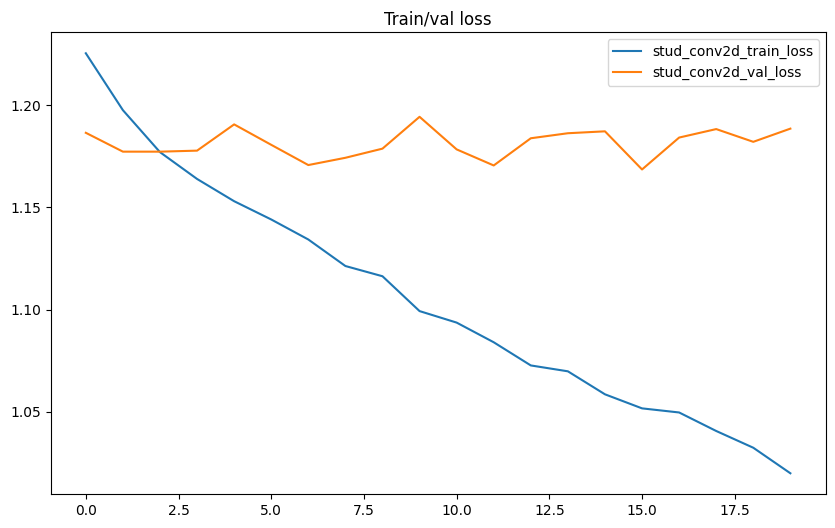

In [73]:
_, ax = plt.subplots(1,1,figsize=(10,6))
ax.set_title('Train/val loss')
ax.plot(metrics_distill_conv2d['stud_conv2d_train_loss'], label='stud_conv2d_train_loss')
ax.plot(metrics_distill_conv2d['stud_conv2d_val_loss'], label='stud_conv2d_val_loss')
ax.legend()

In [74]:
max_f1_stud_distill_conv2d = max(metrics_distill_conv2d['stud_conv2d_val_f1'])
print(f"best f1 stud: {max_f1_stud_distill_conv2d:.5f}")

best f1 stud: 0.59763


In [ ]:
del teacher_model_trained
del student_model_distill_trained
del trainable_conv2d

# Preds

(14, 32, 32, 3) (14, 1)


<Figure size 1600x1200 with 0 Axes>

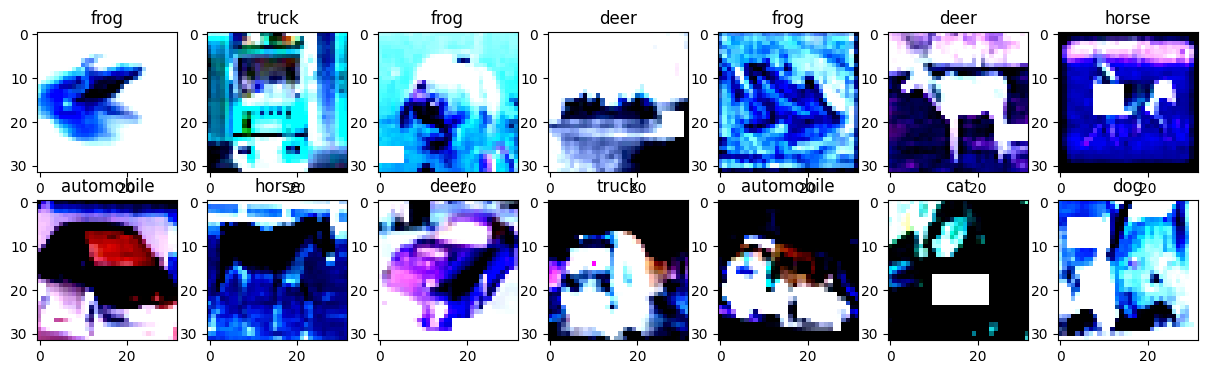

In [88]:
cnt = 14
imgs = []
preds = []
with torch.no_grad():
    for i in range(cnt):
        image, label = val_ds[i]
        pred = student_model_distill_trained(image.to(device).unsqueeze(0))
        pred = pred.argmax(-1)
        imgs.append(image.cpu().numpy().transpose((1, 2, 0)))
        preds.append(pred.cpu().numpy())

imgs = np.array(imgs)
preds = np.array(preds)
print(imgs.shape, preds.shape)

plt.figure(dpi=250)
fig, ax = plt.subplots(2, 7, figsize=(15, 4))
for i in range(7):
    ax[0, i].set_title(classes[preds[i][0]])
    ax[0, i].imshow(imgs[i])

    ax[1, i].set_title(classes[preds[(i+7)][0]])
    ax[1, i].imshow(imgs[(i+7)])
    

In [143]:
import gc
gc.collect()
torch.cuda.empty_cache()